In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.metrics import ConfusionMatrixDisplay

In [7]:
df = pd.read_csv('train.csv')

In [8]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [9]:
important = df[['Survived','Pclass','Age','SibSp','Parch','Fare']]
print(important.head())

   Survived  Pclass   Age  SibSp  Parch     Fare
0         0       3  22.0      1      0   7.2500
1         1       1  38.0      1      0  71.2833
2         1       3  26.0      0      0   7.9250
3         1       1  35.0      1      0  53.1000
4         0       3  35.0      0      0   8.0500


In [15]:
print("Missing values:")
print(important.isnull().sum())

Missing values:
Survived      0
Pclass        0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64


In [16]:
df = important.dropna()
print("After cleaning:", df.shape)

After cleaning: (714, 6)


In [17]:
X_lin = df[['Pclass','Age','SibSp','Parch']]
y_lin = df['Fare']

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

In [18]:
lin = LinearRegression()
lin.fit(X_train_lin, y_train_lin)
pred_lin = lin.predict(X_test_lin)

print("LINEAR REGRESSION")
print("MSE:", mean_squared_error(y_test_lin, pred_lin))
print("R2:", r2_score(y_test_lin, pred_lin))

LINEAR REGRESSION
MSE: 3424.5685181617578
R2: 0.177436773223145


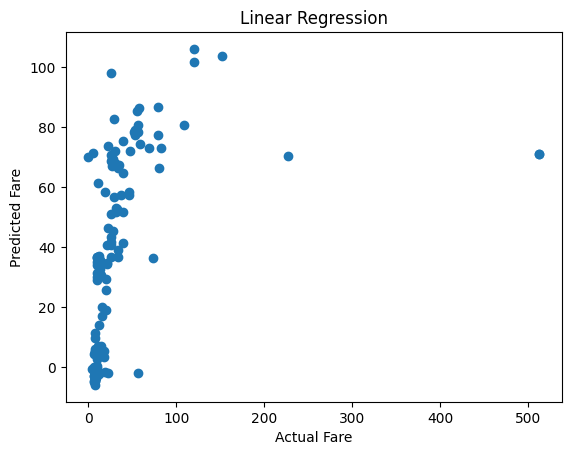

In [19]:
plt.scatter(y_test_lin, pred_lin)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Linear Regression")
plt.show()

In [20]:
X_log = df[['Pclass','Age','SibSp','Parch','Fare']]
y_log = df['Survived']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

In [21]:
log = LogisticRegression(max_iter=5000)
log.fit(X_train_log, y_train_log)
pred_log = log.predict(X_test_log)

print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test_log, pred_log))

LOGISTIC REGRESSION
Accuracy: 0.6993006993006993


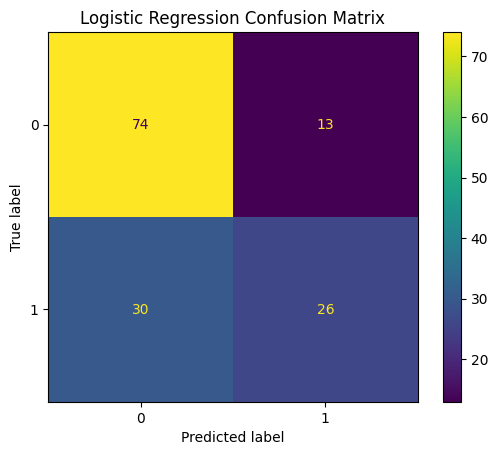

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test_log, pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()